In [98]:
import numpy as  np
import pandas as pd


In [99]:
df=pd.read_csv('place.csv')

In [100]:
df.head()
# shows the first five rows of a data set

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [101]:
df.shape
# shows number of rows and number of columns (rows,column)

(100, 4)

In [102]:
# preprocessing+exploratory data analysis+feature Selection
# Extract input and output cols
# scale the values
# train test split
# Train the model
# evaluate the model
# deploy the model

In [103]:
df=df.iloc[:,1:]

In [104]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [105]:
import matplotlib.pyplot as plt


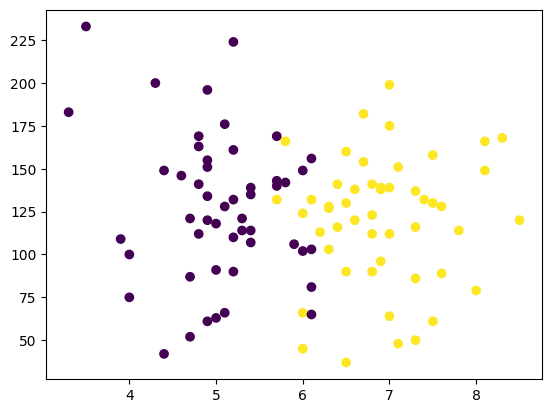

In [106]:
plt.scatter(x=df['cgpa'],y=df['iq'],c=df['placement'])

In [107]:
# logistic regression as eda
# input->independent ,output->dependent on inputs


In [108]:
# seprate input and output
x=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [109]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [110]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [111]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1)
# x is a independent variable and y is dependent variable means output

In [112]:
x_train

,cgpa,iq
87,5.7,132.0
72,7.3,116.0
73,4.9,61.0
70,6.3,127.0
28,5.2,90.0
...,...,...
69,8.5,120.0
0,6.8,123.0
68,4.0,75.0
48,6.6,138.0


In [113]:
x_test

,cgpa,iq
97,6.7,182.0
78,6.1,81.0
55,7.8,114.0
80,4.9,196.0
5,7.1,48.0
62,6.0,102.0
66,6.9,96.0
11,6.9,138.0
81,5.4,107.0
23,4.7,87.0


In [114]:
y_train

,placement
87,1
72,1
73,0
70,1
28,0
...,...
69,1
0,1
68,0
48,1


In [115]:
y_test

,placement
97,1
78,0
55,1
80,0
5,1
62,0
66,1
11,1
81,0
23,0


In [116]:
# scaling
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)


In [117]:
x_train
# dataframe to array all the values comes between -1 to 1

array([[-0.22753566,  0.19058136],
       [ 1.1608175 , -0.21720045],
       [-0.92171223, -1.61895044],
       [ 0.29309678,  0.06314955],
       [-0.66139602, -0.8798459 ],
       [-0.66139602,  0.9296859 ],
       [-0.57462394, -0.26817318],
       [ 0.46664092, -0.8798459 ],
       [ 0.03278056, -2.02673226],
       [-0.22753566,  0.39447227],
       [ 0.90050128,  1.28649499],
       [ 0.03278056, -1.49151863],
       [-0.92171223,  0.67482227],
       [-0.48785187,  0.26704045],
       [ 0.72695714, -0.31914591],
       [ 0.72695714, -0.8798459 ],
       [ 0.11955263,  0.80225409],
       [-0.14076358,  1.05711772],
       [ 1.76822201, -1.1601959 ],
       [-1.09525638, -1.84832771],
       [ 1.33436164,  0.85322681],
       [ 0.64018507,  0.75128136],
       [ 0.90050128,  0.36898591],
       [ 0.72695714,  0.41995863],
       [ 0.37986885, -0.21720045],
       [-0.74816809,  1.31198135],
       [-0.83494016, -0.16622773],
       [-0.66139602,  0.19058136],
       [ 0.90050128,

In [118]:
x_test

array([[ 0.64018507,  1.46489954],
       [ 0.11955263, -1.10922317],
       [ 1.59467786, -0.26817318],
       [-0.92171223,  1.82170862],
       [ 0.98727336, -1.95027317],
       [ 0.03278056, -0.57400954],
       [ 0.81372921, -0.72692772],
       [ 0.81372921,  0.34349954],
       [-0.48785187, -0.44657772],
       [-1.09525638, -0.95630499]])

In [119]:
from sklearn.linear_model import LogisticRegression

In [120]:
clf=LogisticRegression()
# clf has power to access the feature that present inside the logistic regression

In [121]:
# model training
clf.fit(x_train,y_train)
# clf.fit(training dataset) basically fit is the function inside the Logistic regression that is mainly used for training the data set

LogisticRegression()

In [122]:
# model evaluation
y_predict=clf.predict(x_test)

In [123]:
y_test

,placement
97,1
78,0
55,1
80,0
5,1
62,0
66,1
11,1
81,0
23,0


In [124]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_predict)

0.8

<Axes: >

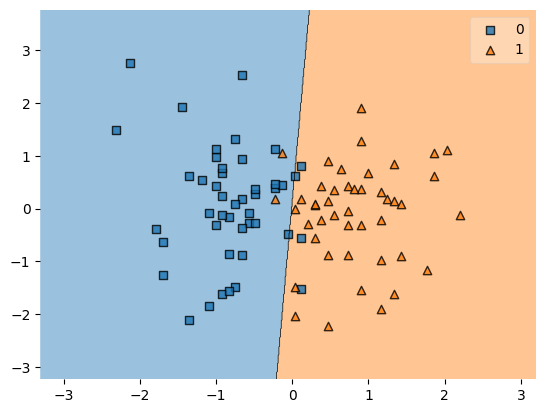

In [128]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x_train,y_train.values,clf=clf)

In [129]:
import pickle

In [130]:
pickle.dump(clf,open('model.pkl','wb'))